In [ ]:
# Installiamo textacy 
!pip install textacy

# Installazione delle librerie necessarie (se non presenti)
!pip install spacy
!python -m spacy download it_core_news_md



In [4]:

import spacy
import pandas as pd
from collections import Counter

# Caricamento del modello "Medium" per l'italiano
# Il modello MD include i Word Vectors, utili per una migliore precisione del NER
nlp = spacy.load("it_core_news_md")

print("Setup completato. Modello spaCy caricato correttamente.")

Setup completato. Modello spaCy caricato correttamente.


In [5]:
# Carichiamo il dataset bilanciato (o quello originale se preferite)
filename = 'LLM_DF_Balanced.csv'

try:
    df = pd.read_csv(filename)
    print(f"Dataset '{filename}' caricato con successo. Righe: {len(df)}")
except FileNotFoundError:
    print(f"Errore: Il file {filename} non è stato trovato. Assicurati di averlo nella stessa cartella.")

# Visualizziamo le prime righe per conferma
df.head()

Dataset 'LLM_DF_Balanced.csv' caricato con successo. Righe: 1044


,Unnamed: 0,comment,title,date,name,stars,sentiment
0,19140,La vera Milano!Sopratutto la domenica per il m...,Peccato per i fighetti,12 ottobre 2018,Mercati C,3.0,neutral
1,17106,Strade fortunati a visitare l'ultima domenica ...,Un'atmosfera straordinaria!,6 novembre 2018,MarOReilly,5.0,positive
2,16660,"non lo so, forse troppo alte le aspettative, m...",niente di che....,28 ottobre 2018,SunflowerLe1989,1.0,negative
3,7996,Non siamo riusciti neanche entrare in Duomo......,Molto affollato,20 marzo 2019,Alb M,3.0,neutral
4,2501,Zona giovanile piena di turisti. I ristoranti ...,Sopravvalutato,3 dicembre 2017,Jacopo C,2.0,negative


In [6]:
def extract_information(text):
    """
    Esegue due task di IE:
    1. Named Entity Recognition (NER): Estrae Luoghi, Organizzazioni e Persone.
    2. Aspect Extraction: Estrae coppie Sostantivo + Aggettivo (es. 'pizza:buona').
    """
    doc = nlp(str(text))
    
    # --- Task 1: NER ---
    # Estraiamo i testi delle entità se appartengono a categorie rilevanti
    entities = [ent.text for ent in doc.ents if ent.label_ in ['LOC', 'ORG', 'PER']]
    
    # --- Task 2: Aspect Extraction ---
    # Cerchiamo i sostantivi e i loro aggettivi collegati (Dependency Parsing)
    aspect_pairs = []
    for token in doc:
        if token.pos_ == "NOUN":
            # Troviamo gli aggettivi che dipendono dal sostantivo
            adjs = [child.text.lower() for child in token.children if child.pos_ == "ADJ"]
            for adj in adjs:
                aspect_pairs.append(f"{token.text.lower()}:{adj}")
                
    return entities, aspect_pairs

print("Funzioni di IE definite.")

Funzioni di IE definite.


In [7]:
print("Inizio estrazione informazioni (potrebbe richiedere qualche minuto)...")

# Applichiamo la funzione e creiamo due nuove colonne
results = df['comment'].apply(extract_information)

df['entities'] = results.apply(lambda x: x[0])
df['aspects'] = results.apply(lambda x: x[1])

print("Estrazione completata!")
# Esempio dei risultati
df[['comment', 'entities', 'aspects']].head(10)

Inizio estrazione informazioni (potrebbe richiedere qualche minuto)...
Estrazione completata!


,comment,entities,aspects
0,La vera Milano!Sopratutto la domenica per il m...,[Alda Merini],[]
1,Strade fortunati a visitare l'ultima domenica ...,"[Cina, Belleek, Copeland piastra, Christophe p...","[strade:fortunati, domenica:ultima, scoperta:o..."
2,"non lo so, forse troppo alte le aspettative, m...",[],[]
3,Non siamo riusciti neanche entrare in Duomo......,[Duomo],[]
4,Zona giovanile piena di turisti. I ristoranti ...,"[Milano, Darsena]","[zona:giovanile, zona:piena, qualità:media, li..."
5,"Essendo una viaggiatrice, ho visitato molti mu...",[],[arti:confusionario]
6,Circa 2700 blocchi in cemento do varie altezze...,[],"[altezze:varie, museo:sottostante, museo:gratu..."
7,Difficilmente un altro monumento riesce a crea...,"[Duomo di Milano, Maestoso]",[monumento:altro]
8,4 pallini per i locali da happy hour (carini e...,"[happy hour, Posso]","[tipo:vario, navigli:sporchi, città:priva, can..."
9,Tempo meglio speso esplorare altre zone della ...,[Venezia],"[zone:altre, località:altre, località:italiane]"


In [8]:
# 1. Quali sono i luoghi/organizzazioni più citati?
all_entities = [ent for sublist in df['entities'] for ent in sublist]
top_entities = Counter(all_entities).most_common(10)

# 2. Quali sono gli aspetti più frequenti nelle recensioni positive vs negative?
pos_aspects = [asp for sublist in df[df['sentiment'] == 'positive']['aspects'] for asp in sublist]
neg_aspects = [asp for sublist in df[df['sentiment'] == 'negative']['aspects'] for asp in sublist]

print("--- TOP 10 ENTITÀ RILEVATE ---")
for ent, count in top_entities:
    print(f"{ent}: {count}")

print("\n--- TOP 5 ASPETTI (Recensioni POSITIVE) ---")
for asp, count in Counter(pos_aspects).most_common(5):
    print(f"{asp}: {count}")

print("\n--- TOP 5 ASPETTI (Recensioni NEGATIVE) ---")
for asp, count in Counter(neg_aspects).most_common(5):
    print(f"{asp}: {count}")

--- TOP 10 ENTITÀ RILEVATE ---
Milano: 178
Navigli: 70
Duomo: 53
Berlino: 53
New York: 43
Central Park: 36
Madrid: 24
Darsena: 21
Manhattan: 19
Italia: 19

--- TOP 5 ASPETTI (Recensioni POSITIVE) ---
parco:immenso: 8
polmone:verde: 7
cielo:aperto: 6
volta:prima: 5
bocca:aperta: 5

--- TOP 5 ASPETTI (Recensioni NEGATIVE) ---
vita:notturna: 4
venditori:abusivi: 4
peccato:vero: 4
zona:piena: 3
zone:altre: 3


In [9]:
# Salvataggio
output_name = 'LLM_DF_IE_Enriched.csv'
df.to_csv(output_name, index=False)

print(f"File salvato come '{output_name}'.")
print("Ora puoi usare questo file per visualizzazioni avanzate o come base per il report d'esame.")

File salvato come 'LLM_DF_IE_Enriched.csv'.
Ora puoi usare questo file per visualizzazioni avanzate o come base per il report d'esame.


In [10]:
# Lista di parole 'vuote' o generiche che sporcano i risultati
ignored_words = {
    'vero', 'altro', 'altri', 'altra', 'altre', 'stesso', 'molto', 'tanto', 
    'poco', 'primo', 'prima', 'secondo', 'cosa', 'cose', 'volta', 'volte', 
    'peccato', 'zona', 'zone', 'pieno', 'piena', 'parte', 'parti'
}

def extract_information_v2(text):
    doc = nlp(str(text))
    
    # Task 1: NER (solitamente già buono, lo manteniamo)
    entities = [ent.text for ent in doc.ents if ent.label_ in ['LOC', 'ORG', 'PER']]
    
    # Task 2: Aspect Extraction con gestione NEGATIVI e FILTRI
    aspect_pairs = []
    for token in doc:
        # Cerchiamo i Sostantivi che non siano nella lista ignore
        if token.pos_ == "NOUN" and token.text.lower() not in ignored_words:
            
            # Verifichiamo se il sostantivo è negato (es. "NON c'è pulizia")
            # Cerchiamo un figlio del token che sia una negazione
            is_negated = any(t.dep_ == "neg" for t in token.children) or \
                         any(t.dep_ == "neg" for t in token.head.children if token.dep_ in ("nsubj", "obj"))

            for child in token.children:
                # Prendiamo aggettivi descrittivi
                if child.pos_ == "ADJ" and child.text.lower() not in ignored_words:
                    adj_text = child.text.lower()
                    
                    # Se abbiamo trovato una negazione vicina, la attacchiamo all'aggettivo
                    if is_negated or any(t.dep_ == "neg" for t in child.children):
                        adj_text = "non_" + adj_text
                    
                    aspect_pairs.append(f"{token.text.lower()}:{adj_text}")
                
    return entities, aspect_pairs

print("Funzione v2 (Ottimizzata) pronta.")

Funzione v2 (Ottimizzata) pronta.


In [11]:
print("Esecuzione estrazione ottimizzata...")

# Applichiamo la v2
results_v2 = df['comment'].apply(extract_information_v2)
df['entities_v2'] = results_v2.apply(lambda x: x[0])
df['aspects_v2'] = results_v2.apply(lambda x: x[1])

print("Completato! Procediamo al confronto statistico.")

Esecuzione estrazione ottimizzata...
Completato! Procediamo al confronto statistico.


In [12]:
def get_top_aspects(df_column, sentiment_val, n=5):
    all_asp = [asp for sublist in df_column[df['sentiment'] == sentiment_val] for asp in sublist]
    return Counter(all_asp).most_common(n)

print("=== CONFRONTO ASPETTI NEGATIVI ===")
print(f"{'VERSIONE v1 (Originale)':<35} | {'VERSIONE v2 (Ottimizzata)':<35}")
print("-" * 75)

v1_neg = get_top_aspects(df['aspects'], 'negative')
v2_neg = get_top_aspects(df['aspects_v2'], 'negative')

for i in range(5):
    t1 = f"{v1_neg[i][0]} ({v1_neg[i][1]})" if i < len(v1_neg) else ""
    t2 = f"{v2_neg[i][0]} ({v2_neg[i][1]})" if i < len(v2_neg) else ""
    print(f"{t1:<35} | {t2:<35}")

print("\n\n=== CONFRONTO ASPETTI POSITIVI ===")
print(f"{'VERSIONE v1 (Originale)':<35} | {'VERSIONE v2 (Ottimizzata)':<35}")
print("-" * 75)

v1_pos = get_top_aspects(df['aspects'], 'positive')
v2_pos = get_top_aspects(df['aspects_v2'], 'positive')

for i in range(5):
    t1 = f"{v1_pos[i][0]} ({v1_pos[i][1]})" if i < len(v1_pos) else ""
    t2 = f"{v2_pos[i][0]} ({v2_pos[i][1]})" if i < len(v2_pos) else ""
    print(f"{t1:<35} | {t2:<35}")

=== CONFRONTO ASPETTI NEGATIVI ===
VERSIONE v1 (Originale)             | VERSIONE v2 (Ottimizzata)          
---------------------------------------------------------------------------
vita:notturna (4)                   | vita:notturna (4)                  
venditori:abusivi (4)               | venditori:abusivi (4)              
peccato:vero (4)                    | livello:basso (3)                  
zona:piena (3)                      | track:fast (3)                     
zone:altre (3)                      | organizzazione:pessima (3)         


=== CONFRONTO ASPETTI POSITIVI ===
VERSIONE v1 (Originale)             | VERSIONE v2 (Ottimizzata)          
---------------------------------------------------------------------------
parco:immenso (8)                   | parco:immenso (8)                  
polmone:verde (7)                   | polmone:verde (7)                  
cielo:aperto (6)                    | cielo:aperto (6)                   
volta:prima (5)                     

C:\Users\User\AppData\Local\Temp\ipykernel_8052\2113456929.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(values), y=list(labels), palette='Reds_r')


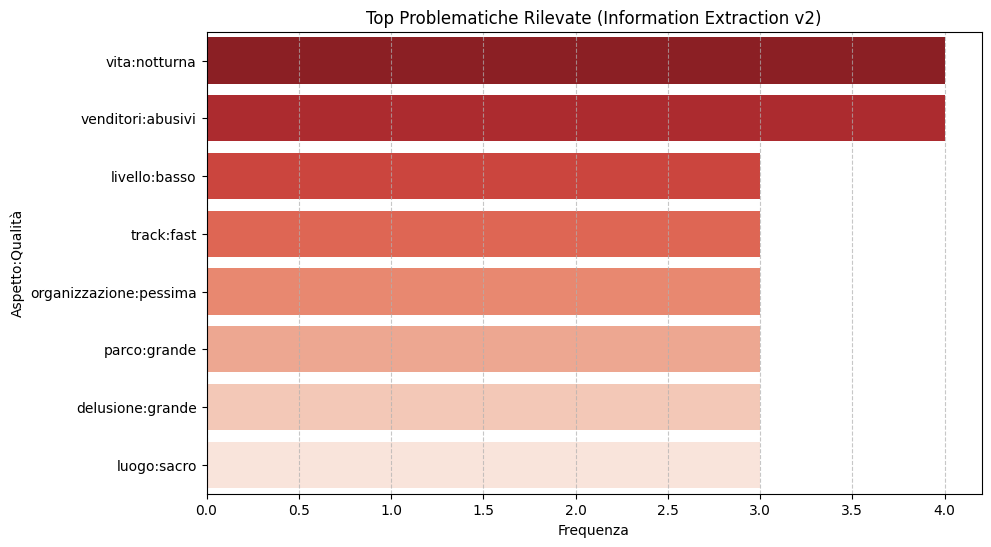

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepariamo i dati per il grafico (usiamo i risultati della v2)
top_neg = get_top_aspects(df['aspects_v2'], 'negative', 8)
labels, values = zip(*top_neg)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(values), y=list(labels), palette='Reds_r')
plt.title('Top Problematiche Rilevate (Information Extraction v2)')
plt.xlabel('Frequenza')
plt.ylabel('Aspetto:Qualità')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [14]:
# Estendiamo la lista delle parole da ignorare con termini temporali e ordinali
extra_ignored = {
    'ultimo', 'ultima', 'ultimi', 'ultime', 'ogni', 'tutti', 'tutto', 
    'pochi', 'poche', 'mese', 'mesi', 'anno', 'anni', 'domenica', 'sabato',
    'giorno', 'giorni', 'settimana', 'fine', 'track', 'fast' # Filtriamo anche il fast track se non ti serve
}
ignored_words.update(extra_ignored)

# Rieseguiamo l'estrazione con i filtri aggiornati
print("Raffinando l'estrazione (v3)...")
results_v3 = df['comment'].apply(extract_information_v2) # La funzione v2 usa ora la lista 'ignored_words' aggiornata
df['aspects_v3'] = results_v3.apply(lambda x: x[1])

# Confronto finale rapido
v3_neg = get_top_aspects(df['aspects_v3'], 'negative', 5)
v3_pos = get_top_aspects(df['aspects_v3'], 'positive', 5)

print("\n--- TOP 5 NEGATIVI (RAFFINATI) ---")
for asp, count in v3_neg: print(f"{asp}: {count}")

print("\n--- TOP 5 POSITIVI (RAFFINATI) ---")
for asp, count in v3_pos: print(f"{asp}: {count}")

Raffinando l'estrazione (v3)...

--- TOP 5 NEGATIVI (RAFFINATI) ---
vita:notturna: 4
venditori:abusivi: 4
livello:basso: 3
organizzazione:pessima: 3
parco:grande: 3

--- TOP 5 POSITIVI (RAFFINATI) ---
parco:immenso: 8
polmone:verde: 7
cielo:aperto: 6
bocca:aperta: 5
parco:grande: 4


In [15]:
# Cerchiamo le recensioni negative che contengono 'parco' e 'grande'
pd.set_option('display.max_colwidth', None) # Per leggere tutto il testo

debug_df = df[(df['sentiment'] == 'negative') & 
              (df['comment'].str.contains('parco', case=False)) & 
              (df['comment'].str.contains('grande', case=False))]

print(f"Trovate {len(debug_df)} recensioni negative con 'parco grande'. Eccone alcune:")
debug_df[['comment', 'aspects_v3']].head(5)

Trovate 3 recensioni negative con 'parco grande'. Eccone alcune:


,comment,aspects_v3
122,Un grande parco nel cuore della città. Abbiamo fittato le bici e percorso tutta la pista ciclabile che è una ed in un unico senso di marcia. Se decidi di tornare indietro.....devi comunque percorrerla tutta. Non si potrebbe creare un doppio senso di marcia? Per guardare le attrazioni devi lasciare la bici (chiuderla con apposito lucchetto) e addentrarti tra il verde senza punti di riferimento. La segnaletica delle attrazioni è inesistente. Nessuno dei turisti presenti sapeva dove si trovassero. Comunque è un'esperienza da fare.....rimane molto da migliorare.,"[parco:grande, pista:ciclabile, senso:unico, senso:doppio, lucchetto:apposito, turisti:presenti]"
463,"Un parco un po' più grande del normale , niente di che. Se una persona passa l'oceano per visitare New York non lo fa di certo per vedere alberi e foglie. Lasciate perdere.",[parco:grande]
978,"È un parco veramente grande, con una strada a senso unico ciclabile che segue il perimetro e tante stradine interne solo pedonali. Ci sono punti attrattivi dove fermarsi ma non sono segnalati, se sei in bici e li salti dovresti fare il giro completo del parco e ritrovarli, una ciclabile a doppio senso sarebbe sensata. Nel complesso non mi ha colpito","[parco:grande, senso:unico, stradine:interne, stradine:pedonali, punti:attrattivi, giro:completo, senso:doppio]"


In [16]:
# Cerchiamo le recensioni positive che contengono 'parco' e 'grande'
pd.set_option('display.max_colwidth', None) # Per leggere tutto il testo

debug_df = df[(df['sentiment'] == 'positive') & 
              (df['comment'].str.contains('parco', case=False)) & 
              (df['comment'].str.contains('grande', case=False))]

print(f"Trovate {len(debug_df)} recensioni positive con 'parco grande'. Eccone alcune:")
debug_df[['comment', 'aspects_v3']].head(5)

Trovate 12 recensioni positive con 'parco grande'. Eccone alcune:


,comment,aspects_v3
82,"Il simbolo di berlino, bella, grande, con la piazza sempre affollata di gente. Bello lo sfondo con il parco alle spalle","[simbolo:bella, simbolo:grande, piazza:affollata]"
87,"Central Park è il cuore di NY, come si può pensare di non visitarlo?BICI - non è difficile noleggiarne una per girare nel parco, attenzione però perché la bici ha un percorso riservato (che essenzialmente percorre il perimetro esterno del parco) e non è consentito girare liberamente per la miriade di vialetti e sentieri che si trovano all'interno del parco.A PIEDI - il parco è molto grande e a piedi si impiega molto tempo per visitarlo ma in questo caso ... non ci sono restrizioni, si può andare ovunque.Consiglio di dare un'occhiata alla mappa del parco e pensare (anche solo sommariamente) al percorso che si vuol fare; come detto il parco è molto grande e all'interno sono numerosi i luoghi da vedere così organizzandosi sicuramente sarà apprezzato meglio.Non dimenticatevi la macchina fotografica (o smartphone) perché gli scorci da immortalare sono innumerevoli.","[percorso:riservato, perimetro:esterno, macchina:fotografica]"
125,"E' il parco dei sogni che vediamo sempre in tv: grande, pulito e molto ordinato tutti dovrebbero passeggiarvi dentro almeno una volta nella vita.",[parco:grande]
239,Central Park è un parco molto grande nel cuore di Manhattan. E' incredibile che sia sopravvissuto alla speculazione edilizia dei decenni passati. Rilassatevi dalla vita frenetica di Manhattan facendo una bella passeggiata.,"[parco:grande, speculazione:edilizia, decenni:passati, vita:frenetica, passeggiata:bella]"
386,"Central Park è senza dubbio una tappa obbligatoria per chi decide di visitare la grande mela!!!! Si possono svolgere diverse attività all'interno di questo immenso parco: dal pattinaggio su ghiaccio a una bella corsa mattutina,da un giro in carrozza(decisamente troppo caro) a un giro immerso nel verde in bicicletta ! Io e la mia ragazza risiedevamo vicino al Museo di Storia Naturale e la mattina era una piacere passeggiare all'interno del parco per arrivare sulla 5th avenue(15minuti di camminata). Il parco è pieno di scoiattoli che si avvicinano ai turisti! Consiglio vivamente la visita del parco per chi trascorre qualche giorno a New York!!!","[tappa:obbligatoria, mela:grande, parco:immenso, corsa:bella, corsa:mattutina, carrozza(decisamente:caro, avenue(15minuti:5th]"


In [17]:
import re

# Sostantivi che non rappresentano veri aspetti della struttura/luogo
abstract_nouns = {
    'mela', 'simbolo', 'tappa', 'giro', 'modo', 'tempo', 'cosa', 'punto', 
    'vostro', 'nostro', 'tutto', 'parte', 'meta', 'idea', 'parere'
}

def extract_information_v4(text):
    # Pulizia preliminare per gestire casi come "carrozza(decisamente"
    text = re.sub(r'([a-zA-Z])\(', r'\1 (', text) # Aggiunge spazio prima della parentesi
    text = re.sub(r'\)([a-zA-Z])', r') \1', text) # Aggiunge spazio dopo
    
    doc = nlp(str(text))
    entities = [ent.text for ent in doc.ents if ent.label_ in ['LOC', 'ORG', 'PER']]
    
    aspect_pairs = []
    for token in doc:
        # CONDIZIONI DI FILTRO AVANZATE:
        # 1. Deve essere un sostantivo
        # 2. Non deve essere nelle liste di parole da ignorare
        # 3. NON deve far parte di una Named Entity (evita "mela" in "Grande Mela")
        if (token.pos_ == "NOUN" and 
            token.text.lower() not in ignored_words and 
            token.text.lower() not in abstract_nouns and
            token.ent_type_ == ""): # <-- Questo esclude le entità nominate
            
            is_negated = any(t.dep_ == "neg" for t in token.children) or \
                         any(t.dep_ == "neg" for t in token.head.children if token.dep_ in ("nsubj", "obj"))

            for child in token.children:
                if child.pos_ == "ADJ" and child.text.lower() not in ignored_words:
                    adj_text = child.text.lower()
                    if is_negated or any(t.dep_ == "neg" for t in child.children):
                        adj_text = "non_" + adj_text
                    
                    aspect_pairs.append(f"{token.text.lower()}:{adj_text}")
                
    return entities, aspect_pairs

# Rieseguiamo l'estrazione definitiva
print("Raffinamento finale in corso...")
df['aspects_expert'] = df['comment'].apply(extract_information_v4).apply(lambda x: x[1])

# Visualizziamo i nuovi risultati per le righe che ti avevano perplesso
print("\n--- RISULTATI PULITI (Esempi precedenti) ---")
final_neg = get_top_aspects(df['aspects_expert'], 'negative', 5)
final_pos = get_top_aspects(df['aspects_expert'], 'positive', 5)

print("\nTOP NEGATIVI:")
for asp, count in final_neg: print(f"{asp}: {count}")
print("\nTOP POSITIVI:")
for asp, count in final_pos: print(f"{asp}: {count}")

Raffinamento finale in corso...

--- RISULTATI PULITI (Esempi precedenti) ---

TOP NEGATIVI:
vita:notturna: 4
venditori:abusivi: 4
livello:basso: 3
organizzazione:pessima: 3
parco:grande: 3

TOP POSITIVI:
parco:immenso: 7
cielo:aperto: 6
polmone:verde: 5
bocca:aperta: 5
posto:magico: 4


### PROVA CON NEUTRALI

In [19]:
# Controlliamo quante recensioni abbiamo per tipo
print("Distribuzione del Sentiment:")
print(df['sentiment'].value_counts())

# Estraiamo i top aspetti anche per le neutrali (se esistono nel tuo CSV)
if 'neutral' in df['sentiment'].values:
    v4_neutral = get_top_aspects(df['aspects_expert'], 'neutral', 5)
    print("\n--- TOP 5 ASPETTI (Recensioni NEUTRALI) ---")
    for asp, count in v4_neutral:
        print(f"{asp}: {count}")
else:
    print("\nNon sono state trovate recensioni con etichetta 'neutral'.")

Distribuzione del Sentiment:
sentiment
neutral     348
positive    348
negative    348
Name: count, dtype: int64

--- TOP 5 ASPETTI (Recensioni NEUTRALI) ---
parco:bel: 6
passeggiata:bella: 4
movida:milanese: 4
parco:grande: 4
guerra:mondiale: 3



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/42.4 MB ? eta -:--:--
     ---------------------------------------- 0.5/42.4 MB 2.8 MB/s eta 0:00:16
      --------------------------------------- 1.0/42.4 MB 2.8 MB/s eta 0:00:15
     - -------------------------------------- 1.6/42.4 MB 2.9 MB/s eta 0:00:15
     -- ------------------------------------- 2.4/42.4 MB 2.9 MB/s eta 0:00:14
     -- ------------------------------------- 2.9/42.4 MB 2.9 MB/s eta 0:00:14
     --- ------------------------------------ 3.7/42.4 MB 3.0 MB/s eta 0:00:13
     --- ------------------------------------ 4.2/42.4 MB 3.0 MB/s eta 0:00:13
     ---- ----------------------------------- 5.0/42.4 MB 3.1 MB/s eta 0:00:13
     ----- ---------------------------------- 5.5/42.4 MB 3.1 MB/s eta 0:00:12
     ----- ---------------------------------- 6.3/42.4 MB 3.1 MB/s eta 0:00:12
     ------ --------------------------------- 7.1/42.4 MB 3.1 MB/s eta 0:00:12
     ------- -------------------------------- 7.6/42.4 MB 3

In [20]:
# Analisi di una recensione neutrale per spiegare il mix di aspetti
print("Esempio di recensione NEUTRALE e i suoi aspetti:")
neutra_esempio = df[df['sentiment'] == 'neutral'].iloc[0]
print(f"TESTO: {neutra_esempio['comment']}")
print(f"ASPETTI ESTRATTI: {neutra_esempio['aspects_expert']}")

Esempio di recensione NEUTRALE e i suoi aspetti:
TESTO: La vera Milano!Sopratutto la domenica per il mercato del antiquariato gli oratori che ti fanno mangiare a due soldi e la gente si tutti i tipi!poi già che siete lì andare alla casa museo di Alda Merini una che li ci ha vissuto e non per gli aperitivi 
ASPETTI ESTRATTI: []


### TEXTRANK E SGRANK

In [18]:
import textacy.extract.keyterms as keyterms

print("Textacy installato e pronto.")

Textacy installato e pronto.


In [19]:
def get_global_keyphrases(texts, algorithm="textrank", n_keywords=10):
    """
    Aggrega una lista di testi in un unico 'super-doc' e estrae le parole chiave.
    Algoritmi disponibili: 'textrank', 'sgrank'.
    """
    # Uniamo i testi in un unico grande blocco
    combined_text = " ".join([str(t) for t in texts])
    doc = nlp(combined_text)
    
    if algorithm == "textrank":
        # TextRank: basa la rilevanza sulla centralità nel grafo delle parole
        return [kps for kps, weights in keyterms.textrank(doc, normalize="lemma", topn=n_keywords)]
    elif algorithm == "sgrank":
        # SGRank: unisce statistiche di frequenza e posizione
        return [kps for kps, weights in keyterms.sgrank(doc, ngrams=(1, 2, 3), normalize="lemma", topn=n_keywords)]
    
print("Funzioni di Keyphrase Extraction definite.")

Funzioni di Keyphrase Extraction definite.


In [20]:
# Dividiamo le recensioni per sentiment
pos_texts = df[df['sentiment'] == 'positive']['comment']
neg_texts = df[df['sentiment'] == 'negative']['comment']

print("--- ANALISI RECENSIONI POSITIVE ---")
print("TextRank:", get_global_keyphrases(pos_texts, algorithm="textrank", n_keywords=7))
print("SGRank:  ", get_global_keyphrases(pos_texts, algorithm="sgrank", n_keywords=7))

print("\n--- ANALISI RECENSIONI NEGATIVE ---")
print("TextRank:", get_global_keyphrases(neg_texts, algorithm="textrank", n_keywords=7))
print("SGRank:  ", get_global_keyphrases(neg_texts, algorithm="sgrank", n_keywords=7))

--- ANALISI RECENSIONI POSITIVE ---
TextRank: ['Bello bello bello', 'bello parco', 'bello Milano', 'bello museo ricco', 'bello zona', 'bello passeggiata', 'bello opera']
SGRank:   ['New York', 'Central Park', 'parco', 'Milano', 'bello', 'visita', 'passeggiata']

--- ANALISI RECENSIONI NEGATIVE ---
TextRank: ['essere straordinario', 'bello poco', 'meglip altro zona visibile', 'altro località italiano', 'zona bello', 'bello locale', 'metà mattino bello coda']
SGRank:   ['zona', 'Milano', 'locale', 'visita', 'biglietto', 'ristorante', 'museo']


In [21]:
def get_global_keyphrases_v2(texts, algorithm="textrank", n_keywords=10):
    # Uniamo le recensioni usando un punto per separarle nettamente
    combined_text = ". ".join([str(t) for t in texts])
    doc = nlp(combined_text)
    
    # Definiamo quali parti del discorso (POS) vogliamo estrarre.
    # Per una vera Information Extraction vogliamo i Sostantivi (NOUN) e Nomi Propri (PROPN)
    # Escludiamo gli aggettivi generici come "bello" per evitare il rumore.
    include_pos = ["NOUN", "PROPN"] 
    
    if algorithm == "textrank":
        # Usiamo 'lower' invece di 'lemma' per leggere meglio il risultato
        return [kps for kps, weights in keyterms.textrank(doc, 
                                                          normalize="lower", 
                                                          include_pos=include_pos, 
                                                          topn=n_keywords)]
    elif algorithm == "sgrank":
        return [kps for kps, weights in keyterms.sgrank(doc, 
                                                        ngrams=(1, 2), # Meglio limitarsi a 1-2 parole
                                                        normalize="lower", 
                                                        include_pos=include_pos, 
                                                        topn=n_keywords)]

print("Analisi globale migliorata: ora estraiamo solo concetti (Sostantivi).")

Analisi globale migliorata: ora estraiamo solo concetti (Sostantivi).


In [23]:
# 1. Dividiamo le recensioni per sentiment
pos_texts = df[df['sentiment'] == 'positive']['comment']
neg_texts = df[df['sentiment'] == 'negative']['comment']

# 2. Eseguiamo l'analisi usando la funzione V2 (Ottimizzata)
print("--- ANALISI GLOBALE: TOP TOPICS (Recensioni POSITIVE) ---")
# Usiamo v2 che filtra i verbi e gli aggettivi inutili
print("TextRank (Concetti):", get_global_keyphrases_v2(pos_texts, algorithm="textrank", n_keywords=7))
print("SGRank (Entità/Nomi):", get_global_keyphrases_v2(pos_texts, algorithm="sgrank", n_keywords=7))

print("\n--- ANALISI GLOBALE: TOP TOPICS (Recensioni NEGATIVE) ---")
print("TextRank (Concetti):", get_global_keyphrases_v2(neg_texts, algorithm="textrank", n_keywords=7))
print("SGRank (Entità/Nomi):", get_global_keyphrases_v2(neg_texts, algorithm="sgrank", n_keywords=7))

--- ANALISI GLOBALE: TOP TOPICS (Recensioni POSITIVE) ---
TextRank (Concetti): ['visita milano', 'ny passeggiata x central park', 'visita new york', 'zona centro', 'visita guida', 'parco', 'milano ludovico sforza']
SGRank (Entità/Nomi): ['new york', 'central park', 'parco', 'milano', 'visita', 'passeggiata', 'duomo']

--- ANALISI GLOBALE: TOP TOPICS (Recensioni NEGATIVE) ---
TextRank (Concetti): ['zona navigli', 'museo domenica', 'quartiere navigli', 'museo reina sofia', 'zona notte', 'zona puzza graffiti', 'milano nn']
SGRank (Entità/Nomi): ['milano', 'zona', 'locali', 'navigli', 'visita', 'museo', 'biglietto']
